# RQ3 — End-to-end clustering → dispatch

So sánh Product-$C_{ij}$, Additive-$C_{ij}$ matched-density và oracle. Công thức context là đúng công thức missing-aware người dùng cung cấp. Truth chỉ được mở sau khi partition và thứ tự policy đã khóa. Kết quả synthetic/illustrative.

In [1]:
# Cài đúng các gói cần thiết nhưng KHÔNG hạ/pin NumPy của Colab.
%pip install -q python-louvain scipy scikit-learn pandas matplotlib

import os, sys, json, hashlib, shutil, zipfile, platform, importlib.metadata
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data')
    WORK_DIR = Path('/content/rq_candidate_v4')
else:
    DATA_DIR = Path.cwd()
    WORK_DIR = Path('/tmp/rq_candidate_v4')
DATA_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

def locate_repo():
    # Local execution (for verification) or an already extracted Colab tree.
    candidates = [Path.cwd(), Path.cwd() / 'nckh2-main', WORK_DIR / 'source']
    for base in candidates:
        if (base / 'demo/data/generate.py').exists():
            return base.resolve()
    zips = sorted(p for p in DATA_DIR.glob('*.zip') if p.name != 'candidate_v4_locked.zip')
    if not zips:
        raise FileNotFoundError(
            'Không thấy source zip trong MyDrive/Colab Notebooks/data. '
            'Hãy upload zip chứa thư mục demo/ rồi chạy lại.'
        )
    extract = WORK_DIR / 'source'
    for source_zip in zips:
        if extract.exists():
            shutil.rmtree(extract)
        extract.mkdir(parents=True)
        with zipfile.ZipFile(source_zip) as archive:
            archive.extractall(extract)
        matches = sorted(extract.rglob('demo/data/generate.py'))
        if matches:
            print('Source zip:', source_zip.name)
            return matches[0].parents[2].resolve()
    raise RuntimeError('Không zip nào trong data chứa demo/data/generate.py')

REPO = locate_repo()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
print('Source repo:', REPO)

Mounted at /content/drive
Source zip: nckh2-main (2).zip
Source repo: /content/rq_candidate_v4/source/nckh2-main (2)/nckh2-main


In [2]:
from demo.data.generate import write_candidate_bundle
from demo.data.schema import GENERATOR_VERSION, FORBIDDEN_INFERENCE_FIELDS, observable_report

CACHE_ZIP = DATA_DIR / 'candidate_v4_locked.zip'
CACHE_SHA = DATA_DIR / 'candidate_v4_locked.sha256'
CACHE_DIR = WORK_DIR / 'candidate_v4_locked'

def deterministic_zip(source_dir, target_zip):
    # Fixed timestamp/order makes the archive hash reproducible.
    tmp = target_zip.with_suffix('.partial.zip')
    with zipfile.ZipFile(tmp, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
        for path in sorted(source_dir.rglob('*')):
            if not path.is_file():
                continue
            rel = path.relative_to(source_dir).as_posix()
            info = zipfile.ZipInfo(rel, date_time=(2026, 1, 1, 0, 0, 0))
            info.compress_type = zipfile.ZIP_DEFLATED
            info.external_attr = 0o644 << 16
            zf.writestr(info, path.read_bytes())
    tmp.replace(target_zip)

def verify_or_create_cache(allow_create=True):
    if CACHE_ZIP.exists():
        actual = sha256_file(CACHE_ZIP)
        if not CACHE_SHA.exists():
            raise RuntimeError('Có candidate_v4_locked.zip nhưng thiếu file .sha256; từ chối dùng cache không xác thực.')
        expected = CACHE_SHA.read_text().strip()
        if actual != expected:
            raise RuntimeError(f'Hash candidate cache sai: expected={expected}, actual={actual}')
    else:
        if not allow_create:
            raise FileNotFoundError('Chưa có candidate_v4_locked.zip; hãy chạy notebook RQ2 trước.')
        build_dir = WORK_DIR / 'candidate_build'
        if build_dir.exists():
            shutil.rmtree(build_dir)
        manifest = write_candidate_bundle(build_dir)
        assert manifest['generator_version'] == GENERATOR_VERSION
        assert len(manifest['entries']) == 80
        deterministic_zip(build_dir, CACHE_ZIP)
        CACHE_SHA.write_text(sha256_file(CACHE_ZIP) + '\n')
    actual = sha256_file(CACHE_ZIP)
    if CACHE_DIR.exists():
        shutil.rmtree(CACHE_DIR)
    CACHE_DIR.mkdir(parents=True)
    with zipfile.ZipFile(CACHE_ZIP) as zf:
        zf.extractall(CACHE_DIR)
    manifest = json.loads((CACHE_DIR / 'manifest.json').read_text())
    mapping = manifest['seed_mapping']
    assert {k: len(v) for k, v in mapping.items()} == {'development': 20, 'calibration': 20, 'test': 40}
    all_seeds = sum((list(v) for v in mapping.values()), [])
    assert len(all_seeds) == len(set(all_seeds)) == 80
    assert all(row['quality_status'] == 'pass' for row in manifest['entries'])
    return manifest, actual

MANIFEST, BUNDLE_SHA256 = verify_or_create_cache(allow_create=True)
print('Candidate:', MANIFEST['generator_version'], '80 runs; SHA256:', BUNDLE_SHA256)

Candidate: 4.1.0 80 runs; SHA256: a7c7a3f7ea63e57f1d98bd42f21c02aa04a69eaa37c824584a2be65f00f2d7e1


## Công thức $C_{ij}$ và calibration không nhãn

Product dùng cấu hình `operational_label_free`. Additive chỉ chọn `(q,k)` trên calibration để khớp retained-edge fraction/mean degree; không đọc ground truth.

In [3]:
import math, heapq
from dataclasses import replace
from collections import defaultdict, Counter
from datetime import datetime
from statistics import mean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from demo.data.generate import candidate_inference_events, load_candidate_dataset
from demo.pipeline.attributes import compute_confidence, haversine_m
from demo.pipeline.config import DEFAULT_CONFIG, WeightParams
from demo.pipeline.priority import score_clusters, REVISED_ESTIMATOR_NAME, LEGACY_ESTIMATOR_NAME
from demo.pipeline.clustering import run_louvain
from demo.pipeline.weighting import sparsify
from demo.experiments.calibration import graph_density, sparsify_at_quantile
from demo.experiments.inference import paired_comparison, apply_holm
from demo.simulation.dispatch import default_resource_scenarios, POLICY_IDS

PRODUCT_CONFIG = {'sigma_geo_m':900.0, 'tau_temp_min':60.0, 'threshold_quantile':0.95,
                  'knn':8, 'resolution':1.2, 'track':'operational_label_free'}
Q_GRID = (0.90,0.925,0.95,0.965,0.975,0.985,0.99)
K_GRID = (4,8,12,16)
DIRECTIONS = {
 'latent_harm':'lower','deadline_miss_rate':'lower','mean_arrival_min':'lower',
 'max_arrival_min':'lower','cvar90_arrival_min':'lower','unique_population_reached_by_deadline_rate':'higher',
 'total_fleet_workload_min':'lower','boat_workload_cv':'lower','arrival_equity_gap_min':'lower',
 'split_trips':'lower','merge_caused_misses':'lower','fake_dispatches':'lower',
 'duplicate_dispatches':'lower','unserved_genuine_incidents':'lower'}
PARETO = ('latent_harm','deadline_miss_rate','mean_arrival_min','arrival_equity_gap_min','total_fleet_workload_min')

def formula_components(events, params):
    n = len(events)
    lat = np.radians(np.array([e.lat for e in events])); lng = np.radians(np.array([e.lng for e in events]))
    dlat=lat[:,None]-lat[None,:]; dlng=lng[:,None]-lng[None,:]
    h=np.sin(dlat/2)**2+np.cos(lat)[:,None]*np.cos(lat)[None,:]*np.sin(dlng/2)**2
    distance=2*6_371_000*np.arcsin(np.sqrt(np.clip(h,0,1)))
    geo=np.exp(-(distance**2)/(2*params.sigma_geo_m**2))
    ts=np.array([e.created_at.timestamp()/60 for e in events])
    temporal=np.exp(-np.abs(ts[:,None]-ts[None,:])/params.tau_temp_min)
    flood=np.array([e.flood for e in events]); urgency=np.array([e.urgency for e in events])
    obs_f=np.array(['flood' not in e.missing_fields for e in events], dtype=float)
    obs_e=np.array(['urgency' not in e.missing_fields for e in events], dtype=float)
    i_f=obs_f[:,None]*obs_f[None,:]; i_e=obs_e[:,None]*obs_e[None,:]
    m=i_f+i_e
    context=(m/2.0)*np.exp(-i_f*np.abs(flood[:,None]-flood[None,:])/params.tau_f
                           -i_e*np.abs(urgency[:,None]-urgency[None,:])/params.tau_e)
    context[m==0]=0.0
    for matrix in (geo,temporal,context): np.fill_diagonal(matrix,0.0)
    return geo, temporal, context, m

def formula_graph(events, mode, q, knn, sigma=900.0, tau=60.0):
    params=replace(DEFAULT_CONFIG.weight,sigma_geo_m=sigma,tau_temp_min=tau,edge_threshold=0.0,knn=knn)
    geo,temp,ctx,m=formula_components(events,params)
    if mode=='product': dense=geo*(params.beta*temp+params.gamma*ctx)
    elif mode=='additive': dense=(geo+temp+ctx)/3.0
    else: raise ValueError(mode)
    sparse, threshold=sparsify_at_quantile(dense,q,knn=knn)
    return sparse, threshold, graph_density(sparse), m

def predict_partition(events, mode, config, seed):
    sparse, threshold, density, _ = formula_graph(events,mode,config['q'],config['knn'])
    labels=run_louvain(sparse,resolution=PRODUCT_CONFIG['resolution'],random_state=int(seed))
    return labels, threshold, density

def calibrate_additive():
    records=[]
    for seed in MANIFEST['seed_mapping']['calibration']:
        events=candidate_inference_events(CACHE_DIR/f'calibration/seed_{seed}.json')
        params=replace(DEFAULT_CONFIG.weight,sigma_geo_m=PRODUCT_CONFIG['sigma_geo_m'],tau_temp_min=PRODUCT_CONFIG['tau_temp_min'])
        geo,temp,ctx,_=formula_components(events,params)
        product_dense=geo*(params.beta*temp+params.gamma*ctx)
        additive_dense=(geo+temp+ctx)/3.0
        product_sparse,_=sparsify_at_quantile(product_dense,PRODUCT_CONFIG['threshold_quantile'],knn=PRODUCT_CONFIG['knn'])
        ref=graph_density(product_sparse)
        for q in Q_GRID:
            for k in K_GRID:
                candidate_sparse,_=sparsify_at_quantile(additive_dense,q,knn=k)
                candidate=graph_density(candidate_sparse)
                records.append({'seed':seed,'q':q,'knn':k,
                  'fraction_error':abs(candidate.retained_fraction-ref.retained_fraction),
                  'degree_relative_error':abs(candidate.mean_degree-ref.mean_degree)/max(ref.mean_degree,1e-12)})
    frame=pd.DataFrame(records)
    choice=(frame.groupby(['q','knn'],as_index=False)[['fraction_error','degree_relative_error']].mean()
            .assign(objective=lambda x:x.fraction_error+x.degree_relative_error)
            .sort_values(['objective','q','knn']).iloc[0])
    return {'q':float(choice.q),'knn':int(choice.knn),'calibration_objective':float(choice.objective)}, frame

def formula_unit_tests():
    from demo.pipeline.attributes import Event
    from datetime import timezone
    base=Event('a',16,108,datetime(2025,1,1,tzinfo=timezone.utc),.2,.8,1,0,False)
    both=replace(base,event_id='b',flood=.5,urgency=.1)
    one=replace(both,event_id='c',missing_fields=('urgency',))
    none=replace(both,event_id='d',missing_fields=('flood','urgency'))
    _,_,ctx,m=formula_components([base,both,one,none],DEFAULT_CONFIG.weight)
    assert np.isclose(ctx[0,1],math.exp(-.3/DEFAULT_CONFIG.weight.tau_f-.7/DEFAULT_CONFIG.weight.tau_e)) and m[0,1]==2
    assert np.isclose(ctx[0,2],.5*math.exp(-.3/DEFAULT_CONFIG.weight.tau_f)) and m[0,2]==1
    assert ctx[0,3]==0 and m[0,3]==0
    assert np.allclose(ctx,ctx.T) and np.isfinite(ctx).all() and ((ctx>=0)&(ctx<=1)).all()
    print('PASS C_ij: m_ij = 2, 1, 0; symmetric, finite, [0,1].')

formula_unit_tests()
ADDITIVE_CONFIG, CALIBRATION_AUDIT = calibrate_additive()
print('Additive matched-density config (không dùng labels):', ADDITIVE_CONFIG)

PASS C_ij: m_ij = 2, 1, 0; symmetric, finite, [0,1].
Additive matched-density config (không dùng labels): {'q': 0.95, 'knn': 8, 'calibration_objective': 0.024220283682757516}


## Mô hình lỗi bảo thủ

Mỗi destination phục vụ tối đa một incident; split tốn 10 phút xác minh, fake-only tốn 15 phút, merge không tự động phục vụ các incident còn lại, và unserved được chấm ở 480 phút.

In [4]:
def build_destinations(data, events, partition, labels):
    groups=defaultdict(list)
    for event,label in zip(events,labels): groups[int(label)].append(event)
    flat=[]; relabel=[]
    for new_label,old in enumerate(sorted(groups)):
        flat.extend(groups[old]); relabel.extend([new_label]*len(groups[old]))
    compute_confidence(flat,DEFAULT_CONFIG.confidence)
    robust={int(x.cluster_id):x for x in score_clusters(flat,relabel,DEFAULT_CONFIG.priority,estimator=REVISED_ESTIMATOR_NAME)}
    legacy={int(x.cluster_id):x for x in score_clusters(flat,relabel,DEFAULT_CONFIG.priority,estimator=LEGACY_ESTIMATOR_NAME)}
    destinations=[]
    for new_label,old in enumerate(sorted(groups)):
        members=groups[old]
        destinations.append({'destination_id':f'{partition}:{new_label}','partition':partition,
          'lat':mean(e.lat for e in members),'lng':mean(e.lng for e in members),
          'province':Counter(e.province for e in members).most_common(1)[0][0],
          'ready_min':min(e.created_at.timestamp()/60 for e in members),
          'revised_priority':float(robust[new_label].priority),'legacy_priority':float(legacy[new_label].priority),
          'workload_proxy':float(robust[new_label].n_total_raw),
          'event_ids':[str(e.event_id) for e in members], 'n_reports':len(members)})
    # Dùng cùng mốc thời gian với latent incident starts. Không đặt báo cáo đầu
    # tiên thành t=0 vì như vậy response time sẽ lệch một hằng số.
    origin=min(datetime.fromisoformat(x['start_at']).timestamp()/60 for x in data['incidents'])
    for d in destinations: d['ready_min']-=origin
    return destinations

def attach_evaluator_truth(data,destinations):
    # Chỉ evaluator gọi hàm này, sau khi partition/priority/policy plan đã khóa.
    report_truth={str(r['event_id']):r['evaluation_only']['incident_id'] for r in data['reports']}
    attached=[]
    for raw in destinations:
        d=dict(raw); linked=[str(report_truth[eid]) for eid in d['event_ids'] if report_truth[eid] is not None]
        d['linked_incidents']=linked; d['n_distinct_linked']=len(set(linked)); attached.append(d)
    return attached

def oracle_destinations(data,events):
    report_truth={str(r['event_id']):r['evaluation_only']['incident_id'] for r in data['reports']}
    incident_label={str(x['incident_id']):i for i,x in enumerate(sorted(data['incidents'],key=lambda x:str(x['incident_id'])))}
    kept=[e for e in events if report_truth[str(e.event_id)] is not None]
    labels=[incident_label[str(report_truth[str(e.event_id)])] for e in kept]
    return attach_evaluator_truth(data,build_destinations(data,kept,'oracle',labels)), labels

def travel_minutes(a,b,c,d,speed): return haversine_m(a,b,c,d)/1000/speed*60
def cvar90(values):
    ordered=sorted(values,reverse=True); return mean(ordered[:max(1,math.ceil(.1*len(ordered)))])
def cv(values):
    mu=mean(values); return 0 if mu<=0 else math.sqrt(mean((x-mu)**2 for x in values))/mu
def harm(incident,response,service_rate,capacity):
    curve=incident['harm_curve']; service=float(incident['service_demand_min'])/service_rate
    late=max(0,response-float(incident['deadline_min'])-float(curve['grace_min']))
    return float(curve['slope'])*late+float(curve['capacity_penalty'])*max(0,service-capacity)

def policy_key(policy,d,decision,travel,max_work,province_counts):
    age=max(0,decision-d['ready_min']); r=min(1,max(0,d['revised_priority']/2)); l=min(1,max(0,d['legacy_priority']/2))
    under=1/(1+province_counts.get(d['province'],0)); workload=d['workload_proxy']/max(max_work,1e-12)
    primary={'revised_priority':r,'legacy_priority':l,'first_report_fifo':age,
             'nearest_first':-travel/180,'equity_aging':.5*r+.3*min(1,age/180)+.2*under,
             'workload_smoothing':.65*r+.25*min(1,age/180)-.1*workload}[policy]
    return (primary,-travel,-d['ready_min'],d['destination_id'])

def lock_dispatch_plan(destinations,scenario,policy):
    # Scheduler chỉ dùng fields quan sát. Proxy service khóa trước kết quả và
    # ngăn latent service/harm thay đổi thứ tự policy trong evaluator.
    boats=[]
    for boat in range(scenario.n_boats):
        depot=scenario.depot_coordinates[boat%len(scenario.depot_coordinates)]; boats.append((0.,boat,*depot))
    heapq.heapify(boats); remaining={d['destination_id']:dict(d) for d in destinations}; province_counts={}; max_work=max(d['workload_proxy'] for d in destinations); plan=[]
    while remaining:
        free,boat,blat,blng=heapq.heappop(boats); eligible=[d for d in remaining.values() if d['ready_min']<=free]
        decision=free
        if not eligible:
            decision=min(d['ready_min'] for d in remaining.values()); eligible=[d for d in remaining.values() if d['ready_min']<=decision]
        choices=[]
        for d in eligible:
            tr=travel_minutes(blat,blng,d['lat'],d['lng'],scenario.speed_kmh); choices.append((policy_key(policy,d,decision,tr,max_work,province_counts),d,tr))
        _,d,tr=max(choices,key=lambda x:x[0])
        proxy_service=min(scenario.nominal_service_capacity_min,max(5.0,d['workload_proxy']/scenario.service_rate))
        plan.append({'destination_id':d['destination_id'],'boat_id':boat,'locked_order':len(plan)})
        province_counts[d['province']]=province_counts.get(d['province'],0)+1; del remaining[d['destination_id']]
        heapq.heappush(boats,(decision+tr+proxy_service,boat,d['lat'],d['lng']))
    assert len(plan)==len({x['destination_id'] for x in plan})==len(destinations)
    return plan

def simulate_partition(data,destinations,scenario,policy,seed):
    locked_plan=lock_dispatch_plan(destinations,scenario,policy)
    destinations=attach_evaluator_truth(data,destinations) if 'linked_incidents' not in destinations[0] else destinations
    by_destination={d['destination_id']:d for d in destinations}
    incidents={str(x['incident_id']):x for x in data['incidents']}; starts=[datetime.fromisoformat(x['start_at']).timestamp()/60 for x in data['incidents']]; origin=min(starts)
    boat_state={boat:(0.,*scenario.depot_coordinates[boat%len(scenario.depot_coordinates)]) for boat in range(scenario.n_boats)}
    served=set(); assignments=[]; workload={b:0. for b in range(scenario.n_boats)}
    merge_incidents=set()
    for d in destinations:
        if d['n_distinct_linked']>1: merge_incidents.update(d['linked_incidents'])
    for planned in locked_plan:
        d=by_destination[planned['destination_id']]; boat=int(planned['boat_id']); free,blat,blng=boat_state[boat]
        decision=max(free,d['ready_min']); tr=travel_minutes(blat,blng,d['lat'],d['lng'],scenario.speed_kmh); arrival=decision+tr
        counts=Counter(i for i in d['linked_incidents'] if i not in served)
        if counts:
            iid=sorted(counts,key=lambda x:(-counts[x],x))[0]; incident=incidents[iid]; served.add(iid)
            response=max(0,arrival-(datetime.fromisoformat(incident['start_at']).timestamp()/60-origin))
            service=float(incident['service_demand_min'])/scenario.service_rate; verification=0.; kind='genuine'
        elif d['linked_incidents']:
            iid=None; response=None; service=0.; verification=10.; kind='duplicate_verification'
        else:
            iid=None; response=None; service=0.; verification=15.; kind='fake_verification'
        cost=tr+service+verification; workload[boat]+=cost
        assignments.append({'seed':seed,'partition':d['partition'],'resource_scenario':scenario.scenario_id,'policy':policy,
          'destination_id':d['destination_id'],'boat_id':boat,'dispatch_kind':kind,'served_incident_id':iid,
          'locked_order':planned['locked_order'],'decision_min':decision,'travel_min':tr,'service_min':service,'verification_min':verification,'workload_min':cost,
          'n_distinct_linked':d['n_distinct_linked']})
        boat_state[boat]=(arrival+service+verification,d['lat'],d['lng'])
    outcomes=[]
    for iid,incident in incidents.items():
        hit=next((a for a in assignments if a['served_incident_id']==iid),None); response=480. if hit is None else float(hit['decision_min']+hit['travel_min']-(datetime.fromisoformat(incident['start_at']).timestamp()/60-origin))
        response=max(0,response); outcomes.append({'iid':iid,'response':response,'miss':response>float(incident['deadline_min']),
          'harm':harm(incident,response,scenario.service_rate,scenario.nominal_service_capacity_min),'n_true':int(incident['n_true']),
          'province':str(incident['province']),'served':hit is not None})
    prov={p:mean(x['response'] for x in outcomes if x['province']==p) for p in sorted({x['province'] for x in outcomes})}
    timely=sum(x['n_true'] for x in outcomes if not x['miss']); total=sum(x['n_true'] for x in outcomes)
    metrics={'latent_harm':mean(x['harm'] for x in outcomes),'deadline_miss_rate':mean(x['miss'] for x in outcomes),
      'mean_arrival_min':mean(x['response'] for x in outcomes),'max_arrival_min':max(x['response'] for x in outcomes),'cvar90_arrival_min':cvar90([x['response'] for x in outcomes]),
      'unique_population_reached_by_deadline_rate':timely/total,'total_fleet_workload_min':sum(workload.values()),'boat_workload_cv':cv(list(workload.values())),
      'arrival_equity_gap_min':max(prov.values())-min(prov.values()),'split_trips':sum(a['dispatch_kind']=='duplicate_verification' for a in assignments),
      'merge_caused_misses':sum((not x['served']) and x['iid'] in merge_incidents for x in outcomes),'fake_dispatches':sum(a['dispatch_kind']=='fake_verification' for a in assignments),
      'duplicate_dispatches':sum(a['dispatch_kind']=='duplicate_verification' for a in assignments),'unserved_genuine_incidents':sum(not x['served'] for x in outcomes)}
    # Accounting invariants.
    assert len(assignments)==len({a['destination_id'] for a in assignments})==len(destinations)
    served_ids=[a['served_incident_id'] for a in assignments if a['served_incident_id'] is not None]
    assert len(served_ids)==len(set(served_ids)); assert np.isclose(sum(a['workload_min'] for a in assignments),sum(workload.values()))
    assert all(a['served_incident_id'] is None for a in assignments if a['dispatch_kind']=='fake_verification')
    return metrics,assignments

def mark_pareto(frame):
    frame=frame.copy(); frame['pareto_nondominated']=True
    for idx,row in frame.iterrows():
        for jdx,other in frame.iterrows():
            if idx==jdx: continue
            if all(other[m]<=row[m] for m in PARETO) and any(other[m]<row[m] for m in PARETO): frame.loc[idx,'pareto_nondominated']=False; break
    return frame

## Chạy 40 test seed × 3 partition × 3 resource × 6 policy

Notebook xuất đầy đủ assignment, outcome, partition loss, paired tests và Pareto frequency; không assert Product/Revised phải thắng.

RQ3: 5/40 test runs
RQ3: 10/40 test runs
RQ3: 15/40 test runs
RQ3: 20/40 test runs
RQ3: 25/40 test runs
RQ3: 30/40 test runs
RQ3: 35/40 test runs
RQ3: 40/40 test runs


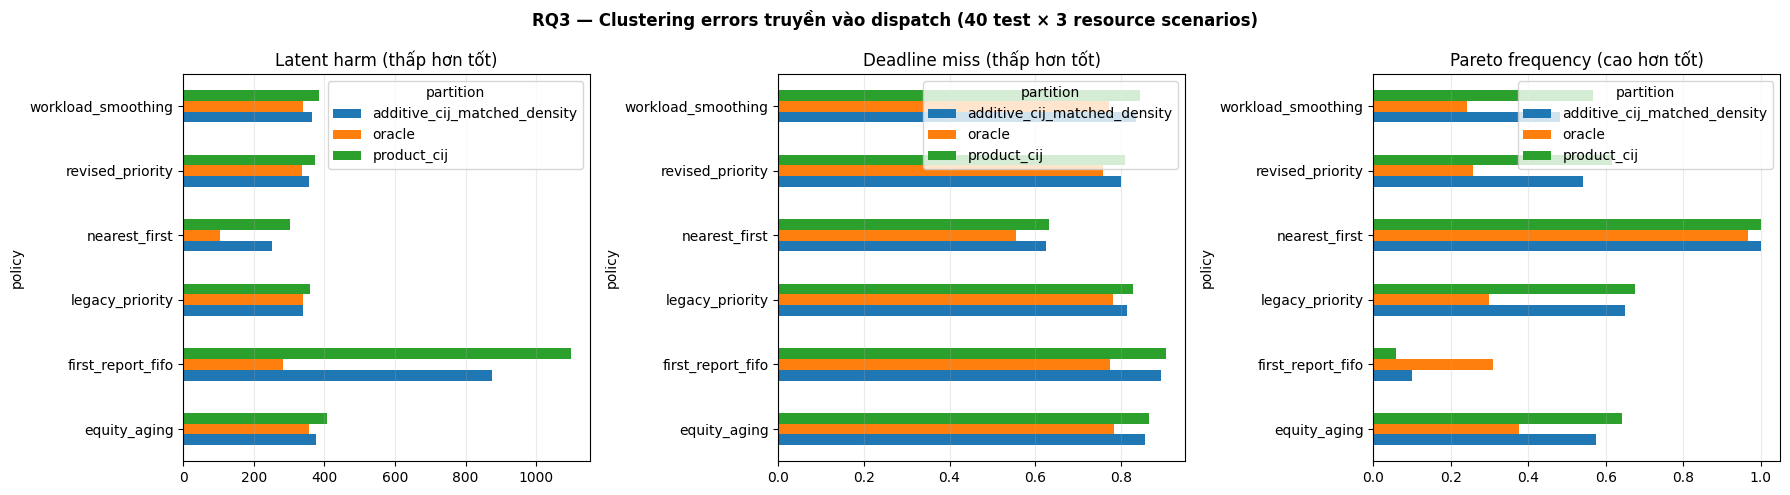

CSV SHA256 (chạy lại cùng code/seed phải giống): {'rq3_destination_assignments.csv': '19326a261e98acfbbffe9ba7ba00b91ab535f84e097a2ef634f118f851a96500', 'rq3_dispatch_test.csv': '7745b83d838051818875749b1ff85ba32d7698f13d39ff99805f6380f00c9449', 'rq3_paired_comparisons.csv': 'cf885f9f95673b6043b5b71eac7eec6de6192e267e4c3fecee2960ef0fd2a3ef', 'rq3_partition_losses.csv': '5b90e539dbaae2be8b664156b45c09a3ed2a2cd98c05c5e63a4c663713200233'}
Đã lưu: /content/drive/MyDrive/Colab Notebooks/data/rq3_results


,partition,policy,latent_harm,deadline_miss_rate,pareto
0,additive_cij_matched_density,equity_aging,376.823926,0.856250,0.575000
1,additive_cij_matched_density,first_report_fifo,875.261900,0.893750,0.100000
2,additive_cij_matched_density,legacy_priority,339.615606,0.815625,0.650000
3,additive_cij_matched_density,nearest_first,252.741255,0.626042,1.000000
4,additive_cij_matched_density,revised_priority,354.968333,0.799479,0.541667
5,additive_cij_matched_density,workload_smoothing,366.044202,0.834375,0.483333
6,oracle,equity_aging,356.923297,0.783854,0.375000
7,oracle,first_report_fifo,283.236419,0.773958,0.308333
8,oracle,legacy_priority,340.173559,0.782813,0.300000
9,oracle,nearest_first,104.391373,0.554167,0.966667


In [5]:
dispatch_rows=[]; assignment_rows=[]; partition_rows=[]
def partition_diagnostics(destinations):
    incident_destinations=defaultdict(set)
    for d in destinations:
        for iid in set(d['linked_incidents']): incident_destinations[iid].add(d['destination_id'])
    split_ids={iid for iid,dids in incident_destinations.items() if len(dids)>1}
    return {
      'n_split_incidents':len(split_ids),
      'n_extra_split_fragments':sum(len(incident_destinations[iid])-1 for iid in split_ids),
      'n_merged_destinations':sum(d['n_distinct_linked']>1 for d in destinations),
      'n_fake_only_destinations':sum(not d['linked_incidents'] for d in destinations),
    }
for position,seed in enumerate(MANIFEST['seed_mapping']['test'],1):
    path=CACHE_DIR/f'test/seed_{seed}.json'; data=load_candidate_dataset(path); events=candidate_inference_events(data)
    product_cfg={'q':PRODUCT_CONFIG['threshold_quantile'],'knn':PRODUCT_CONFIG['knn']}
    plabels,pthr,pden=predict_partition(events,'product',product_cfg,seed)
    alabels,athr,aden=predict_partition(events,'additive',ADDITIVE_CONFIG,seed)
    p_dest=build_destinations(data,events,'product_cij',plabels); a_dest=build_destinations(data,events,'additive_cij_matched_density',alabels); o_dest,_=oracle_destinations(data,events)
    for name,dests,density,threshold in [('product_cij',p_dest,pden,pthr),('additive_cij_matched_density',a_dest,aden,athr),('oracle',o_dest,None,None)]:
        evaluation_destinations=attach_evaluator_truth(data,dests) if 'linked_incidents' not in dests[0] else dests
        partition_rows.append({'seed':seed,'partition':name,'n_destinations':len(dests),'retained_edge_fraction':None if density is None else density.retained_fraction,
          'mean_degree':None if density is None else density.mean_degree,'threshold':threshold, **partition_diagnostics(evaluation_destinations)})
        for scenario in default_resource_scenarios():
            batch=[]
            for policy in POLICY_IDS:
                metrics,assignments=simulate_partition(data,dests,scenario,policy,seed)
                row={'seed':seed,'stage':'test','partition':name,'resource_scenario':scenario.scenario_id,'policy':policy,**metrics}
                batch.append(row); assignment_rows.extend(assignments)
            marked=mark_pareto(pd.DataFrame(batch)); dispatch_rows.extend(marked.to_dict('records'))
    if position%5==0: print(f'RQ3: {position}/40 test runs')

dispatch=pd.DataFrame(dispatch_rows); assignments=pd.DataFrame(assignment_rows); partitions=pd.DataFrame(partition_rows)
assert dispatch.seed.nunique()==40 and set(dispatch.partition)=={'product_cij','additive_cij_matched_density','oracle'}
PKG={name:importlib.metadata.version(name) for name in ('numpy','pandas','scipy','scikit-learn','python-louvain')}
META={'generator_version':MANIFEST['generator_version'],'seed_split':'test:3000-3039','candidate_bundle_sha256':BUNDLE_SHA256,
      'package_versions':json.dumps(PKG,sort_keys=True),'config_identity':json.dumps({'product':PRODUCT_CONFIG,'additive':ADDITIVE_CONFIG,'error_model':'conservative-v1'},sort_keys=True),
      'metric_direction':json.dumps(DIRECTIONS,sort_keys=True)}
for frame in (dispatch,assignments,partitions):
    for k,v in META.items(): frame[k]=v

comparisons=[]
def compare_pair(candidate,comparator,dimension,fixed):
    subset=dispatch.copy()
    for col,val in fixed.items(): subset=subset[subset[col]==val]
    keys=['seed','resource_scenario']
    left=subset[subset[dimension]==candidate].set_index(keys); right=subset[subset[dimension]==comparator].set_index(keys); common=sorted(set(left.index)&set(right.index))
    family={m:paired_comparison([left.loc[x,m] for x in common],[right.loc[x,m] for x in common],direction=d,denominator={'paired_seed_resource_runs':len(common)}) for m,d in DIRECTIONS.items()}
    for metric,result in apply_holm(family).items(): comparisons.append({'dimension':dimension,'candidate':candidate,'comparator':comparator,'fixed':json.dumps(fixed,sort_keys=True),'metric':metric,**result})

for partition in dispatch.partition.unique():
    for comparator in ('legacy_priority','nearest_first','first_report_fifo'):
        compare_pair('revised_priority',comparator,'policy',{'partition':partition})
for policy in POLICY_IDS:
    compare_pair('product_cij','oracle','partition',{'policy':policy})
    compare_pair('product_cij','additive_cij_matched_density','partition',{'policy':policy})
comparisons=pd.json_normalize(comparisons,sep='.')
for k,v in META.items(): comparisons[k]=v

OUT=DATA_DIR/'rq3_results'; OUT.mkdir(exist_ok=True)
assignments.to_csv(OUT/'rq3_destination_assignments.csv',index=False,float_format='%.10g')
dispatch.to_csv(OUT/'rq3_dispatch_test.csv',index=False,float_format='%.10g')
partitions.to_csv(OUT/'rq3_partition_losses.csv',index=False,float_format='%.10g')
comparisons.to_csv(OUT/'rq3_paired_comparisons.csv',index=False,float_format='%.10g')

fig,axes=plt.subplots(1,3,figsize=(18,5))
view=dispatch.groupby(['partition','policy'],as_index=False).agg(latent_harm=('latent_harm','mean'),deadline_miss_rate=('deadline_miss_rate','mean'),pareto=('pareto_nondominated','mean'))
for ax,metric,title in zip(axes,('latent_harm','deadline_miss_rate','pareto'),('Latent harm (thấp hơn tốt)','Deadline miss (thấp hơn tốt)','Pareto frequency (cao hơn tốt)')):
    pivot=view.pivot(index='policy',columns='partition',values=metric); pivot.plot.barh(ax=ax); ax.set_title(title); ax.grid(axis='x',alpha=.25)
fig.suptitle('RQ3 — Clustering errors truyền vào dispatch (40 test × 3 resource scenarios)',fontweight='bold')
fig.tight_layout(); fig.savefig(OUT/'rq3_dispatch_results.png',dpi=180,bbox_inches='tight'); plt.show()
artifact_hashes={p.name:sha256_file(p) for p in sorted(OUT.glob('rq3_*.csv'))}
(OUT/'rq3_artifact_sha256.json').write_text(json.dumps(artifact_hashes,indent=2,sort_keys=True)+'\n')
print('CSV SHA256 (chạy lại cùng code/seed phải giống):',artifact_hashes)
print('Đã lưu:',OUT)
display(view)